In [57]:
import pandas as pd 

#use given directory since the csv is too big for github
merged = pd.read_csv("/Users/gianellarobles/Downloads/sample_2013/merged_mortgage_2013.csv")

#all columns for the dataset
merged.columns

/var/folders/63/h0zgkssd48bbn8s4xmhg8hs40000gn/T/ipykernel_93362/3220488591.py:4: DtypeWarning: Columns (3,7,23,24,28,56,57,58,59) have mixed types. Specify dtype option on import or set low_memory=False.
  merged = pd.read_csv("/Users/gianellarobles/Downloads/sample_2013/merged_mortgage_2013.csv")


Index(['loan_sequence_number', 'monthly_reporting_period',
       'current_actual_upb', 'current_loan_delinquency_status', 'loan_age',
       'remaining_months_to_legal_maturity', 'defect_settlement_date',
       'modification_flag', 'zero_balance_code', 'zero_balance_effective_date',
       'current_interest_rate', 'current_deferred_upb',
       'due_date_of_last_paid_installment', 'mi_recoveries',
       'net_sales_proceeds', 'non_mi_recoveries', 'expenses', 'legal_costs',
       'maintenance_and_preservation_costs', 'taxes_and_insurance',
       'miscellaneous_expenses', 'actual_loss_calculation',
       'modification_cost', 'step_modification_flag', 'deferred_payment_plan',
       'estimated_loan_to_value', 'zero_balance_removal_upb',
       'delinquent_accrued_interest', 'delinquency_due_to_disaster',
       'borrower_assistance_status_code', 'current_month_modification_cost',
       'interest_bearing_upb', 'credit_score', 'first_payment_date',
       'first_time_homebuyer_flag', 

In [58]:
#count missing values
missing_count = merged.isnull().sum()

#percentage missing
missing_percent = (merged.isnull().sum() / len(merged)) * 100

#combine into one table
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percent": missing_percent
})

#sort from most missing to least
missing_summary = missing_summary.sort_values(
    by="Missing Percent",
    ascending=False
)

#high missing count only
display(missing_summary[missing_summary["Missing Count"] > 0])

,Missing Count,Missing Percent
defect_settlement_date,4132380,99.997871
legal_costs,4132170,99.992789
mi_recoveries,4132170,99.992789
miscellaneous_expenses,4132170,99.992789
taxes_and_insurance,4132170,99.992789
maintenance_and_preservation_costs,4132170,99.992789
expenses,4132170,99.992789
non_mi_recoveries,4132170,99.992789
delinquent_accrued_interest,4132169,99.992765
net_sales_proceeds,4132169,99.992765


In [59]:
#columns that can be dropped 

drop_columns = [
    "defect_settlement_date",
    "legal_costs",
    "mi_recoveries",
    "miscellaneous_expenses",
    "taxes_and_insurance",
    "maintenance_and_preservation_costs",
    "expenses",
    "non_mi_recoveries",
    "delinquent_accrued_interest",
    "net_sales_proceeds",
    "actual_loss_calculation",
    "modification_cost",
    "current_month_modification_cost", 
    "harp_indicator",
    "pre_harp_loan_sequence_number",
    "super_conforming_flag"
]

merged.drop(columns=drop_columns, inplace=True)

print(merged.columns)

Index(['loan_sequence_number', 'monthly_reporting_period',
       'current_actual_upb', 'current_loan_delinquency_status', 'loan_age',
       'remaining_months_to_legal_maturity', 'modification_flag',
       'zero_balance_code', 'zero_balance_effective_date',
       'current_interest_rate', 'current_deferred_upb',
       'due_date_of_last_paid_installment', 'step_modification_flag',
       'deferred_payment_plan', 'estimated_loan_to_value',
       'zero_balance_removal_upb', 'delinquency_due_to_disaster',
       'borrower_assistance_status_code', 'interest_bearing_upb',
       'credit_score', 'first_payment_date', 'first_time_homebuyer_flag',
       'maturity_date', 'metropolitan_statistical_area',
       'mortgage_insurance_percentage', 'number_of_units', 'occupancy_status',
       'original_combined_loan_to_value', 'original_debt_to_income_ratio',
       'original_unpaid_principal_balance', 'original_loan_to_value',
       'original_interest_rate', 'channel', 'prepayment_penalty_mort

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

#sample loans for testing - 5000 loans
np.random.seed(42)

unique_loan = merged["loan_sequence_number"].dropna().unique()

sample_size = min(5000, len(unique_loan))

selected_loans = np.random.choice(
    unique_loan,
    size=sample_size,
    replace=False
)

rf_data = merged[
    merged["loan_sequence_number"].isin(selected_loans)
].copy()

rf_data = rf_data.sort_values(
    by=["loan_sequence_number", "monthly_reporting_period"]
)

print("Row: ", len(rf_data))
print("Unique loans: ", rf_data["loan_sequence_number"].nunique())



Row:  412897
Unique loans:  5000


In [61]:
#convert to binary status 0 or 1
    #1=90+ days delinquent 
    #0=current or fewer than 90 days delinquent
def changeDelinquency(status):
   if pd.isna(status):
      return np.nan
   status = str(status).strip().upper()

   if status == "XX":
      return np.nan
   if status == "R":
      return 1

   try: 
      return 1 if int(float(status)) >= 3 else 0
   except (ValueError, TypeError):
      return np.nan

In [62]:
#current month status
rf_data["changeDelinquency"] = (
    rf_data["current_loan_delinquency_status"]
    .apply(changeDelinquency)
)

In [63]:
rf_data["next_month_serious_delinquency"] = (
    rf_data.groupby("loan_sequence_number")["changeDelinquency"]
    .shift(-1)
)

In [64]:
#check next month code for serious delinquency

rf_data[
    [
        "loan_sequence_number",
        "monthly_reporting_period",
        "changeDelinquency",
        "next_month_serious_delinquency"
    ]
].head(10)

#check rows where target changes/becomes delinquent

rf_data.loc[
    rf_data["next_month_serious_delinquency"] == 1,
    [
        "loan_sequence_number",
        "monthly_reporting_period",
        "changeDelinquency",
        "next_month_serious_delinquency"
    ]
].head(10)



,loan_sequence_number,monthly_reporting_period,changeDelinquency,next_month_serious_delinquency
82022,F13Q10042609,201604,0.0,1.0
82023,F13Q10042609,201605,1.0,1.0
82024,F13Q10042609,201606,1.0,1.0
82025,F13Q10042609,201607,1.0,1.0
82026,F13Q10042609,201608,1.0,1.0
96241,F13Q10050308,201306,0.0,1.0
96242,F13Q10050308,201307,1.0,1.0
108392,F13Q10057449,201809,0.0,1.0
108393,F13Q10057449,201810,1.0,1.0
108394,F13Q10057449,201811,1.0,1.0


In [65]:
rf_data.groupby("loan_sequence_number").tail(1)[
    [
        "loan_sequence_number",
        "monthly_reporting_period",
        "next_month_serious_delinquency"
    ]
].head()

,loan_sequence_number,monthly_reporting_period,next_month_serious_delinquency
361,F13Q10000257,201605,NaN
4719,F13Q10002672,201507,NaN
5934,F13Q10003672,202507,NaN
6613,F13Q10004621,201908,NaN
9980,F13Q10006146,201512,NaN


In [66]:
#removing the last month record
rf_data = rf_data.dropna(
    subset=["next_month_serious_delinquency"]
).copy()

#convert target from float to integer
rf_data["next_month_serious_delinquency"] = (
    rf_data["next_month_serious_delinquency"].astype(int)
)

print("Rows remaining: ", rf_data.shape[0])

print("\nTarget counts: ")
print(
    rf_data["next_month_serious_delinquency"]
    .value_counts()
    .sort_index()
)

print("\nTarget percentages: ")
print(
    rf_data["next_month_serious_delinquency"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(4)
)

Rows remaining:  407712

Target counts: 
next_month_serious_delinquency
0    405867
1      1845
Name: count, dtype: int64

Target percentages: 
next_month_serious_delinquency
0    99.5475
1     0.4525
Name: proportion, dtype: float64


In [67]:
#choosing the model columns to input
features = [
    "current_actual_upb",
    "current_interest_rate",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "current_deferred_upb",
    "interest_bearing_upb",
    "credit_score",
    "mortgage_insurance_percentage",
    "number_of_units",
    "original_combined_loan_to_value",
    "original_debt_to_income_ratio",
    "original_unpaid_principal_balance",
    "original_loan_to_value",
    "original_interest_rate",
    "original_loan_term",
    "number_of_borrowers",
    "estimated_loan_to_value"
]

target = "next_month_serious_delinquency"

print("Number of features: ", len(features))

Number of features:  17


In [68]:
#look for missing columns 
missing_columns = [
    column
    for column in features
    if column not in rf_data.columns
]

print("Missing columns: ", missing_columns)
#confirmed empty

Missing columns:  []


In [69]:
#convert features to numeric
for column in features: 
    rf_data[column] = pd.to_numeric(
        rf_data[column],
        errors="coerce"
    )

print(rf_data[features].dtypes)
#all numeric now

current_actual_upb                    float64
current_interest_rate                 float64
loan_age                                int64
remaining_months_to_legal_maturity      int64
current_deferred_upb                  float64
interest_bearing_upb                  float64
credit_score                            int64
mortgage_insurance_percentage           int64
number_of_units                         int64
original_combined_loan_to_value         int64
original_debt_to_income_ratio           int64
original_unpaid_principal_balance       int64
original_loan_to_value                  int64
original_interest_rate                float64
original_loan_term                      int64
number_of_borrowers                     int64
estimated_loan_to_value               float64
dtype: object


In [70]:
#create model dataset
model_data = rf_data[
    ["loan_sequence_number"] + features + [target]
].copy()

print("Model data shape: ", model_data.shape)

model_data.head()

Model data shape:  (407712, 19)


,loan_sequence_number,current_actual_upb,current_interest_rate,loan_age,remaining_months_to_legal_maturity,current_deferred_upb,interest_bearing_upb,credit_score,mortgage_insurance_percentage,number_of_units,original_combined_loan_to_value,original_debt_to_income_ratio,original_unpaid_principal_balance,original_loan_to_value,original_interest_rate,original_loan_term,number_of_borrowers,estimated_loan_to_value,next_month_serious_delinquency
323,F13Q10000257,150000.0,2.75,0,180,0.0,150000.0,792,0,1,47,26,150000,47,2.75,180,2,NaN,0
324,F13Q10000257,149000.0,2.75,1,179,0.0,149000.0,792,0,1,47,26,150000,47,2.75,180,2,NaN,0
325,F13Q10000257,149000.0,2.75,2,178,0.0,149000.0,792,0,1,47,26,150000,47,2.75,180,2,NaN,0
326,F13Q10000257,148000.0,2.75,3,177,0.0,148000.0,792,0,1,47,26,150000,47,2.75,180,2,NaN,0
327,F13Q10000257,147000.0,2.75,4,176,0.0,147000.0,792,0,1,47,26,150000,47,2.75,180,2,NaN,0


In [71]:
#creating X, y, and loan groups
X = model_data[features]
y = model_data[target]
groups = model_data["loan_sequence_number"]

print("X shape: ", X.shape)
print("y shape: ", y.shape)
print("Unique loans: ", groups.nunique())


X shape:  (407712, 17)
y shape:  (407712,)
Unique loans:  4997


In [72]:
#split data by loan
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    splitter.split(
        X, 
        y,
        groups=groups
    )
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

train_loans = groups.iloc[train_index]
test_loans = groups.iloc[test_index]

print("X train: ", X_train.shape)
print("X test: ", X_test.shape)
print("y train: ", y_train.shape)
print("y test: ", y_test.shape)

X train:  (324890, 17)
X test:  (82822, 17)
y train:  (324890,)
y test:  (82822,)


In [73]:
#look for overlapping loans
overlapping_loans = set(
    train_loans.unique()
).intersection(
    set(test_loans.unique())
)

print("Training loans: ", train_loans.nunique())
print("Testing loans: ", test_loans.nunique())
print("Overlapping loans: ", len(overlapping_loans))
#confirmed no overlap

Training loans:  3997
Testing loans:  1000
Overlapping loans:  0


In [74]:
training_medians = X_train.median()

X_train = X_train.fillna(training_medians)
X_test = X_test.fillna(training_medians)

#if column is missing and has no median
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

print("Missing values in X train: ", X_train.isnull().sum().sum())
print("Missing values in X test: ", X_test.isnull().sum().sum())


Missing values in X train:  0
Missing values in X test:  0


In [75]:
#class imbalance

print("Training target counts: ", y_train.value_counts().sort_index())

print("\nTraining target percentages: ", y_train.value_counts(normalize=True).sort_index().mul(100).round(4))

print("\nTesting target counts: ", y_test.value_counts().sort_index())

Training target counts:  next_month_serious_delinquency
0    323433
1      1457
Name: count, dtype: int64

Training target percentages:  next_month_serious_delinquency
0    99.5515
1     0.4485
Name: proportion, dtype: float64

Testing target counts:  next_month_serious_delinquency
0    82434
1      388
Name: count, dtype: int64


In [76]:
from sklearn.ensemble import RandomForestClassifier

#Train Random Forest Tree Model
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print("Training Random Forest: \n")
random_forest.fit(
    X_train, 
    y_train
)

print("\nTraining completed")

Training Random Forest: 



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    3.5s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   16.9s



Training completed


[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:   18.3s finished


In [77]:
#create predictions
rf_predictions = random_forest.predict(X_test)

rf_probabilities = random_forest.predict_proba(X_test)[:, 1]

print("Predictions created")

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s


Predictions created


[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished


In [78]:
#calculate evaluation metrics
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)
rf_precision = precision_score(
    y_test,
    rf_predictions,
    zero_division=0
)
rf_recall=recall_score(
    y_test,
    rf_predictions, 
    zero_division=0
)
rf_f1 = f1_score(
    y_test,
    rf_predictions,
    zero_division=0
)
rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)
print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-score: {rf_f1:.4f}")
print(f"ROC-AUC: {rf_auc:.4f}")

Accuracy: 0.9865
Precision: 0.0054
Recall: 0.0103
F1-score: 0.0071
ROC-AUC: 0.7771


In [79]:
#Classification report
print("Random Forest Classification Report:\n")

print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=[
            "Not Seriously Delinquent",
            "Seriously Delinquent"
        ],
        zero_division=0
    )
)

Random Forest Classification Report:

                          precision    recall  f1-score   support

Not Seriously Delinquent       1.00      0.99      0.99     82434
    Seriously Delinquent       0.01      0.01      0.01       388

                accuracy                           0.99     82822
               macro avg       0.50      0.50      0.50     82822
            weighted avg       0.99      0.99      0.99     82822



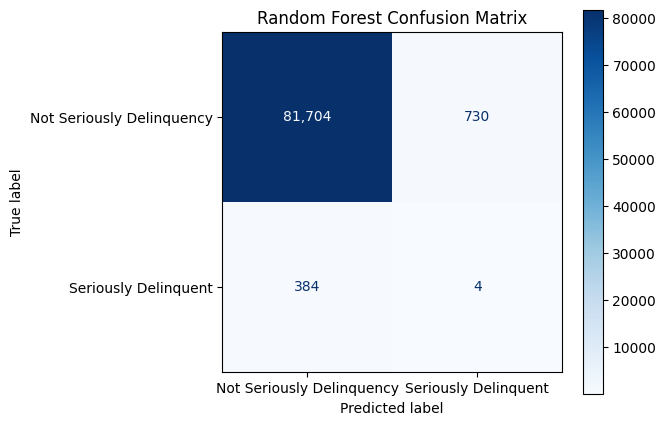

In [80]:
#confusion matrix
rf_confusion_matrix = confusion_matrix(
    y_test,
    rf_predictions
)

matrix_display = ConfusionMatrixDisplay(
    confusion_matrix=rf_confusion_matrix,
    display_labels=[
        "Not Seriously Delinquency",
        "Seriously Delinquent"
    ]
)
matrix_display.plot(values_format=",d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

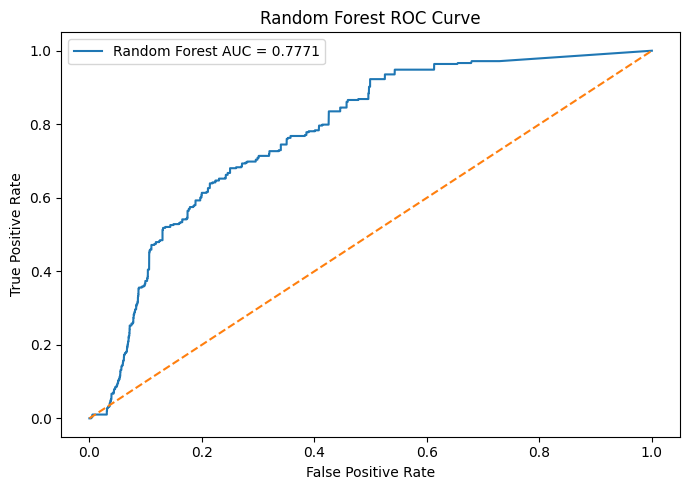

In [81]:
from sklearn.metrics import roc_curve

#ROC curve
false_positive_rate, true_positive_rate, thresholds = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    label=f"Random Forest AUC = {rf_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [82]:
#important features
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": random_forest.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance

,Feature,Importance
0,credit_score,0.171314
1,loan_age,0.093475
2,remaining_months_to_legal_maturity,0.082515
3,estimated_loan_to_value,0.077181
4,original_debt_to_income_ratio,0.074345
5,current_interest_rate,0.068775
6,current_actual_upb,0.064260
7,interest_bearing_upb,0.062737
8,original_combined_loan_to_value,0.062720
9,original_loan_to_value,0.060976


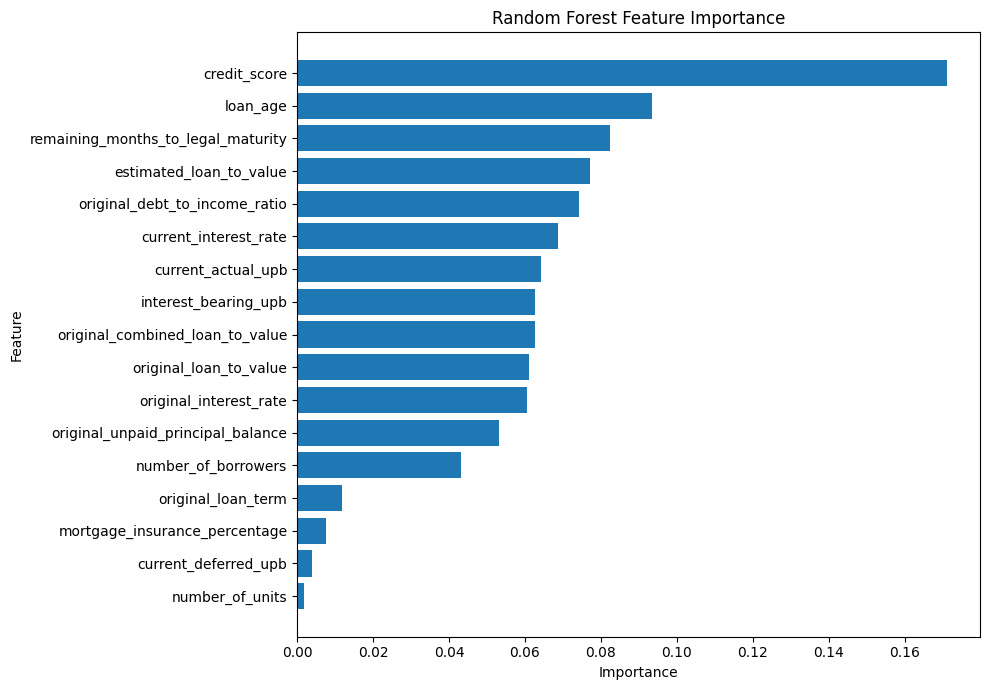

In [83]:
#feature importance graph
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [84]:
#needs improvements - lower classification 
rf_predictions = random_forest.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 184 tasks      | elapsed:    0.1s
[Parallel(n_jobs=8)]: Done 200 out of 200 | elapsed:    0.1s finished


In [86]:
threshold = 0.1

rf_predictions_adjusted = (
    rf_probabilities >= threshold
).astype(int)

In [ ]:
print(f"Threshold: {threshold}")

print(
    classification_report(
        y_test,
        rf_predictions_adjusted,
        target_names=[
            "Not Seriously Delinquent",
            "Seriously Delinquent"
        ],
        zero_division=0
    )
)

Threshold: 0.1
                          precision    recall  f1-score   support

Not Seriously Delinquent       1.00      0.89      0.94     82434
    Seriously Delinquent       0.02      0.47      0.04       388

                accuracy                           0.88     82822
               macro avg       0.51      0.68      0.49     82822
            weighted avg       0.99      0.88      0.93     82822



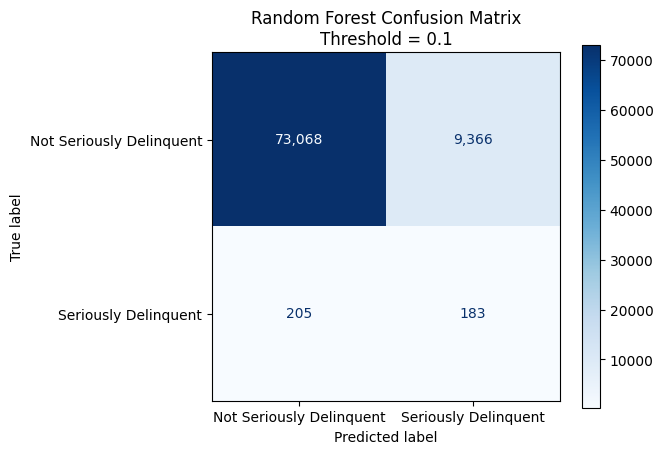

In [ ]:
adjusted_cm = confusion_matrix(
    y_test,
    rf_predictions_adjusted
)

adjusted_display = ConfusionMatrixDisplay(
    confusion_matrix=adjusted_cm,
    display_labels=[
        "Not Seriously Delinquent",
        "Seriously Delinquent"
    ]
)

adjusted_display.plot(
    values_format=",d",
    cmap="Blues"
)

plt.title(
    f"Random Forest Confusion Matrix\nThreshold = {threshold}"
)

plt.tight_layout()
plt.show()

In [ ]:
for threshold in [0.50, 0.30, 0.20, 0.10, 0.05]:
    predictions = (
        rf_probabilities >= threshold
    ).astype(int)

    print(
        f"Threshold {threshold:.2f} | "
        f"Precision: {precision_score(y_test, predictions, zero_division=0):.4f} | "
        f"Recall: {recall_score(y_test, predictions, zero_division=0):.4f} | "
        f"F1: {f1_score(y_test, predictions, zero_division=0):.4f}"
    )

Threshold 0.50 | Precision: 0.0054 | Recall: 0.0103 | F1: 0.0071
Threshold 0.30 | Precision: 0.0038 | Recall: 0.0258 | F1: 0.0067
Threshold 0.20 | Precision: 0.0115 | Recall: 0.1418 | F1: 0.0212
Threshold 0.10 | Precision: 0.0192 | Recall: 0.4716 | F1: 0.0368
Threshold 0.05 | Precision: 0.0143 | Recall: 0.5928 | F1: 0.0280


In [88]:
# Random Forest Models Using 12-month sequential loan data

#still using the cleaned dataframe created for name, value in globals().items():

for name, value in list(globals().items()):
    if isinstance(value, pd.DataFrame):
        print(name, value.shape)


_ (17, 2)
__ (5, 19)
___ (5, 3)
merged (4132468, 47)
missing_summary (63, 2)
_12 (63, 2)
rf_data (407712, 49)
_23 (10, 4)
_24 (10, 4)
_25 (5, 3)
model_data (407712, 19)
_33 (5, 19)
X (407712, 17)
X_train (324890, 17)
X_test (82822, 17)
feature_importance (17, 2)
_47 (17, 2)
_64 (10, 4)
_65 (5, 3)
_70 (5, 19)
_82 (17, 2)


In [103]:
#start with the cleaned merged dataset
sequential_data = rf_data.copy()

print("Sequential data shape: ", sequential_data.shape)

sequential_data = sequential_data.sort_values(
    ["loan_sequence_number", "monthly_reporting_period"]
).reset_index(drop=True)

Sequential data shape:  (407712, 49)


In [105]:
#sequential data preprocessing
sequence_length = 12
random_state = 42

sequential_features = [
    "current_actual_upb",
    "current_interest_rate",
    "loan_age",
    "remaining_months_to_legal_maturity",
    "interest_bearing_upb",
    "credit_score",
    "mortgage_insurance_percentage",
    "original_debt_to_income_ratio",
    "original_loan_to_value",
    "original_interest_rate",
    "number_of_borrowers",
    "estimated_loan_to_value",
    "current_loan_delinquency_status",
    "current_deferred_upb",
]

target = "next_month_serious_delinquency"

print("Features: ", len(sequential_features))
print("Target: ", target)

Features:  14
Target:  next_month_serious_delinquency


In [106]:
#create 12-month sequences for each loan
def create_12month_sequences(data, features_columns, sequence_length):
    X = []
    y = []
    loan_ids = []
    target_months = []

    for loan_id, loan_history in data.groupby("loan_sequence_number"):
        loan_history = loan_history.sort_values(
            "monthly_reporting_period"
        )
        if len(loan_history) < sequence_length:
            continue

        for i in range(len(loan_history) - sequence_length):
            sequence = loan_history.iloc[i:i + sequence_length]
            target_row = loan_history.iloc[i + sequence_length]

        X.append(sequence[features_columns].values.flatten())

        y.append(target_row[target])
        loan_ids.append(loan_id)
        target_months.append(target_row["monthly_reporting_period"])

    return (
        np.array(X),
        np.array(y),
        loan_ids,
        target_months
    )

In [107]:
#split loan id 
from sklearn.model_selection import train_test_split

loan_ids = sequential_data["loan_sequence_number"].unique()

train_loans, test_loans = train_test_split(
    loan_ids,
    test_size=0.2,
    random_state=random_state
)
train_loans, validation_loans = train_test_split(
    train_loans,
    test_size=0.2,
    random_state=random_state
)

train_data = sequential_data[
    sequential_data["loan_sequence_number"].isin(train_loans)
]

test_data = sequential_data[
    sequential_data["loan_sequence_number"].isin(test_loans)
]

validation_data = sequential_data[
    sequential_data["loan_sequence_number"].isin(validation_loans)
]

print("Train data shape: ", train_data.shape)
print("Validation data shape: ", validation_data.shape)
print("Test data shape: ", test_data.shape)

#training - 64% split
#validation - 16% split
#testing - 20% split

Train data shape:  (259254, 49)
Validation data shape:  (65636, 49)
Test data shape:  (82822, 49)


In [108]:
print("next_month_serious_delinquency" in sequential_data.columns)

True


In [109]:
print("next_month_serious_delinquency" in rf_data.columns)

True


In [110]:
X_train_seq, y_train_seq, train_ids, train_months = (create_12month_sequences(
    train_data,
    sequential_features,
    sequence_length
)
)

X_validation_seq, y_validation_seq, val_ids, val_target_months = (create_12month_sequences(
    validation_data,
    sequential_features,
    sequence_length
)
)

X_test_seq, y_test_seq, test_ids, test_target_months = (create_12month_sequences(
    test_data,
    sequential_features,
    sequence_length
)
)

print("X train shape: ", X_train_seq.shape)
print("y train shape: ", y_train_seq.shape)
print("X validation shape: ", X_validation_seq.shape)
print("y validation shape: ", y_validation_seq.shape)
print("X test shape: ", X_test_seq.shape)
print("y test shape: ", y_test_seq.shape)

X train shape:  (3084, 168)
y train shape:  (3084,)
X validation shape:  (777, 168)
y validation shape:  (777,)
X test shape:  (963, 168)
y test shape:  (963,)
